#Deep Learning Based DDoS Attack Detection

Import Libraries and Models

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.utils import to_categorical
from sklearn.svm import SVC

Load Dataset and Preprocessing

In [ ]:
    df = pd.read_csv("/content/Portmap.csv")
    print("Data shape:", df.shape)
    print("Class distribution:\n", df['Label'].value_counts())
    # Drop non-numeric or irrelevant columns
    drop_cols = ['SourceIP', 'DestinationIP', 'Protocol', 'Timestamp', 'Unnamed: 0', 'Unnamed0']
    df.drop([col for col in drop_cols if col in df.columns], axis=1, inplace=True)

    normal_terms = ['normal', 'benign']
    df['Label'] = df['Label'].astype(str).str.lower().str.strip()
    df['Label'] = df['Label'].apply(lambda x: 0 if x in normal_terms else 1)

    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(0, inplace=True)

    for col in df.columns:
        if df[col].dtype in ['float64', 'int64']:
            df[col] = df[col].clip(-1e10, 1e10)
        elif df[col].dtype == 'object':
            try:
                df[col] = pd.to_numeric(df[col])
            except:
                df.drop(col, axis=1, inplace=True)


<ipython-input-2-4cab4c3ec767>:1: DtypeWarning: Columns (85) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/Portmap.csv")


Data shape: (191694, 88)
Class distribution:
 Label
Portmap    186960
BENIGN       4734
Name: count, dtype: int64


Splitting Dataset (Training and Testing)

In [ ]:
X = df.drop('Label', axis=1).values
y = df['Label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = np.nan_to_num(X_train, nan=0, posinf=1e10, neginf=-1e10)
X_test = np.nan_to_num(X_test, nan=0, posinf=1e10, neginf=-1e10)

X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (153355, 1, 81)
Test shape: (38339, 1, 81)


SVM Model

In [ ]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train_svm, y_train_svm)

y_pred_svm = svm_model.predict(X_test_svm)
print("SVM Accuracy:", accuracy_score(y_test_svm, y_pred_svm))
print(classification_report(y_test_svm, y_pred_svm))


SVM Accuracy: 0.9996870027908917
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       930
           1       1.00      1.00      1.00     37409

    accuracy                           1.00     38339
   macro avg       0.99      1.00      1.00     38339
weighted avg       1.00      1.00      1.00     38339



CNN Model

In [ ]:

X_reshaped = X.reshape((X.shape[0], X.shape[1], 1))
y_cnn = to_categorical(y)

# Split the data
X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(X_reshaped, y_cnn, test_size=0.2, random_state=42)

cnn_model = Sequential()
cnn_model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X.shape[1], 1)))
cnn_model.add(MaxPooling1D(pool_size=2))
cnn_model.add(Flatten())
cnn_model.add(Dense(100, activation='relu'))
cnn_model.add(Dropout(0.5))
cnn_model.add(Dense(y_cnn.shape[1], activation='softmax'))

cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn_model.fit(X_train_cnn, y_train_cnn, epochs=10, batch_size=64, validation_data=(X_test_cnn, y_test_cnn))

y_pred_cnn = cnn_model.predict(X_test_cnn)

y_pred_cnn_classes = np.argmax(y_pred_cnn, axis=1)
y_test_cnn_classes = np.argmax(y_test_cnn, axis=1)

print("CNN Model Accuracy:", accuracy_score(y_test_cnn_classes, y_pred_cnn_classes))
print(classification_report(y_test_cnn_classes, y_pred_cnn_classes))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
2397/2397 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9894 - loss: 16791.0273 - val_accuracy: 0.9858 - val_loss: 5106.2173
Epoch 2/10
2397/2397 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9811 - loss: 1760.2997 - val_accuracy: 0.9815 - val_loss: 154.4837
Epoch 3/10
2397/2397 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9790 - loss: 64.5700 - val_accuracy: 0.9812 - val_loss: 0.3345
Epoch 4/10
2397/2397 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9796 - loss: 0.2467 - val_accuracy: 0.9795 - val_loss: 0.0896
Epoch 5/10
2397/2397 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9830 - loss: 0.4431 - val_accuracy: 0.9788 - val_loss: 0.1059
Epoch 6/10
2397/2397 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9770 - loss: 1.6667 - val_accuracy: 0.9773 - val_loss: 0.1077
Epoch 7/10
2397/2397 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9764 - loss: 0.1222 - val_accuracy: 0.9770 - val_loss: 1.9576
Epoch 8/10
2397/2397 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.976

LSTM Model

In [ ]:
def lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(64, input_shape=input_shape, return_sequences=True))
    model.add(Dropout(0.3))
    model.add(LSTM(32))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

    return model

model = lstm_model((X_train.shape[1], X_train.shape[2]))

history = model.fit(X_train, y_train, validation_split=0.2, epochs=10)

test_pred = (model.predict(X_test) > 0.5).astype(int)
test_accuracy = accuracy_score(y_test, test_pred)
print("LSTM Model Accuracy: ", test_accuracy)
print(classification_report(y_test, test_pred))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
3834/3834 ━━━━━━━━━━━━━━━━━━━━ 32s 7ms/step - accuracy: 0.9945 - loss: 0.0562 - val_accuracy: 0.9989 - val_loss: 0.0034
Epoch 2/10
3834/3834 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - accuracy: 0.9991 - loss: 0.0027 - val_accuracy: 0.9989 - val_loss: 0.0027
Epoch 3/10
3834/3834 ━━━━━━━━━━━━━━━━━━━━ 29s 8ms/step - accuracy: 0.9995 - loss: 0.0015 - val_accuracy: 0.9991 - val_loss: 0.0016
Epoch 4/10
3834/3834 ━━━━━━━━━━━━━━━━━━━━ 40s 7ms/step - accuracy: 0.9996 - loss: 0.0012 - val_accuracy: 0.9994 - val_loss: 0.0011
Epoch 5/10
3834/3834 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - accuracy: 0.9997 - loss: 9.2115e-04 - val_accuracy: 0.9996 - val_loss: 0.0011
Epoch 6/10
3834/3834 ━━━━━━━━━━━━━━━━━━━━ 41s 8ms/step - accuracy: 0.9997 - loss: 9.3428e-04 - val_accuracy: 0.9999 - val_loss: 9.1314e-04
Epoch 7/10
3834/3834 ━━━━━━━━━━━━━━━━━━━━ 27s 7ms/step - accuracy: 0.9998 - loss: 7.8971e-04 - val_accuracy: 0.9997 - val_loss: 9.3573e-04
Epoch 8/10
3834/3834 ━━━━━━━━━━━━━━━━━━━━ 43s 8ms/step - accura

Models Comparison

SVM Accuracy: 0.9996870027908917
CNN Model Accuracy: 0.9764991262161246
LSTM Model Accuracy:  0.9999217506977229


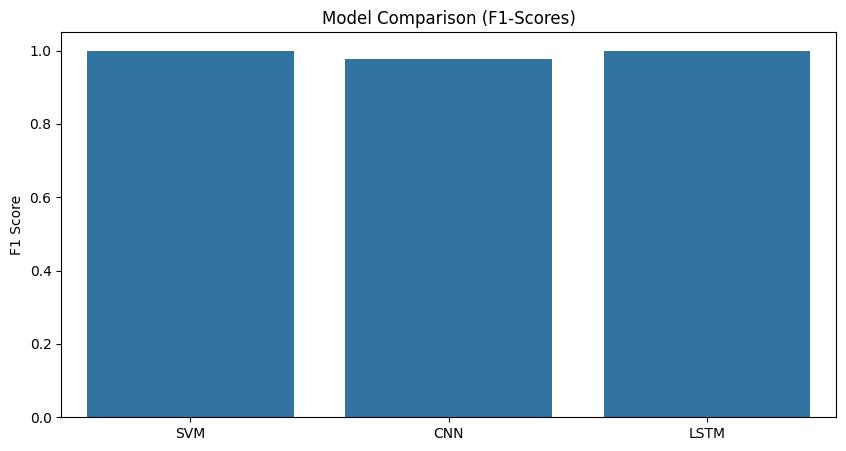

In [ ]:
print("SVM Accuracy:", accuracy_score(y_test_svm, y_pred_svm))
print("CNN Model Accuracy:", accuracy_score(y_test_cnn_classes, y_pred_cnn_classes))
print("LSTM Model Accuracy: ", test_accuracy)

models = ['SVM', 'CNN', 'LSTM']
accuracy_scores = [
    accuracy_score(y_test_svm, y_pred_svm),
    accuracy_score(y_test_cnn_classes, y_pred_cnn_classes),
    accuracy_score(y_test, test_pred)
]

plt.figure(figsize=(10, 5))
sns.barplot(x=models, y=accuracy_scores)
plt.title("Model Comparison (F1-Scores)")
plt.ylabel("F1 Score")
plt.show()